<a href="https://colab.research.google.com/github/vitalinamysiv/restaurant-visitor-forecasting/blob/main/notebooks/01_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
!python src/create_dataset.py

Загрузка данных...
Размер исходных данных: (1017209, 5)
Готово!
Размер обработанных данных: (844392, 4)
Сохранено: data/processed/restaurant_daily.csv


In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!git clone https://github.com/vitalinamysiv/restaurant-visitor-forecasting.git

Cloning into 'restaurant-visitor-forecasting'...
remote: Enumerating objects: 58, done.
remote: Counting objects: 100% (58/58), done.
remote: Compressing objects: 100% (42/42), done.
remote: Total 58 (delta 11), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (58/58), 20.80 KiB | 887.00 KiB/s, done.
Resolving deltas: 100% (11/11), done.


In [3]:
%cd restaurant-visitor-forecasting

/content/restaurant-visitor-forecasting


In [4]:
!ln -s /content/drive/MyDrive/restaurant_forecasting/data/raw/train.csv data/raw/train.csv

!ln -s /content/drive/MyDrive/restaurant_forecasting/data/raw/store.csv data/raw/store.csv

In [6]:
!ls data

processed  raw


In [8]:
!ls data/processed

restaurant_daily.csv


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv(
    "data/processed/restaurant_daily.csv",
    parse_dates=["date"]
)

df.head()

,restaurant_id,date,revenue,guests
0,1,2013-01-02,5530,668
1,1,2013-01-03,4327,578
2,1,2013-01-04,4486,619
3,1,2013-01-05,4997,635
4,1,2013-01-07,7176,785


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 844392 entries, 0 to 844391
Data columns (total 4 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   restaurant_id  844392 non-null  int64         
 1   date           844392 non-null  datetime64[ns]
 2   revenue        844392 non-null  int64         
 3   guests         844392 non-null  int64         
dtypes: datetime64[ns](1), int64(3)
memory usage: 25.8 MB


In [11]:
print("Начало периода:", df["date"].min())
print("Конец периода:", df["date"].max())

days = (
    df["date"].max() - df["date"].min()
).days

print("Количество дней:", days)
print("Количество лет:", round(days / 365, 2))

Начало периода: 2013-01-01 00:00:00
Конец периода: 2015-07-31 00:00:00
Количество дней: 941
Количество лет: 2.58


In [12]:
print(
    "Количество ресторанов:",
    df["restaurant_id"].nunique()
)

Количество ресторанов: 1115


In [13]:
df.isna().sum()

,0
restaurant_id,0
date,0
revenue,0
guests,0


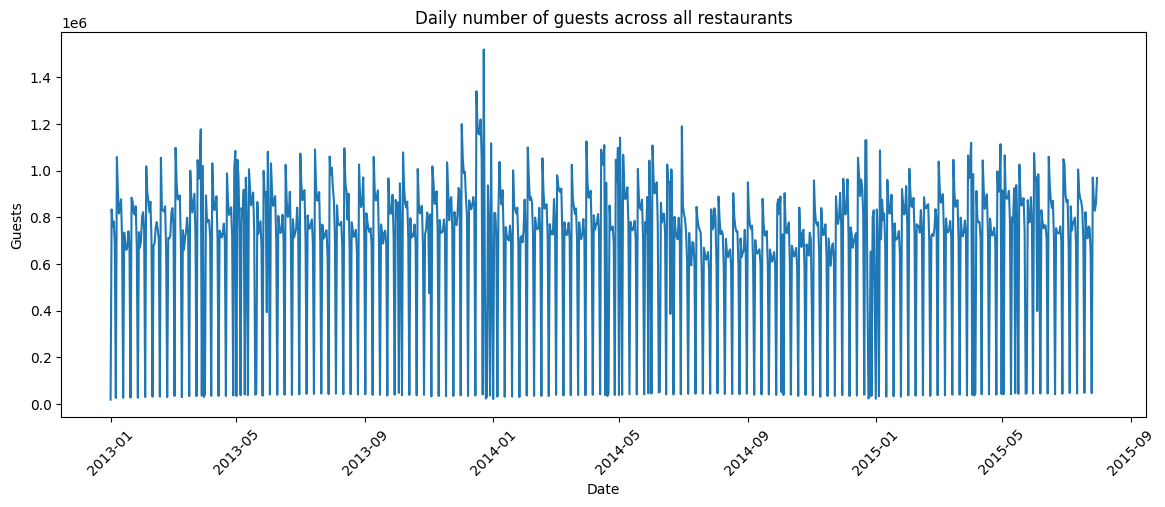

In [14]:
daily = (
    df
    .groupby("date")
    ["guests"]
    .sum()
    .reset_index()
)


plt.figure(figsize=(14,5))

plt.plot(
    daily["date"],
    daily["guests"]
)

plt.title(
    "Daily number of guests across all restaurants"
)

plt.xlabel(
    "Date"
)

plt.ylabel(
    "Guests"
)

plt.xticks(rotation=45)

plt.show()

Вывод:

На временном ряду наблюдаются изменения уровня посещаемости во времени.
Для модели важно учитывать календарные признаки и исторические значения посещаемости (лаги), так как спрос зависит от предыдущих периодов.

In [15]:
df["day_of_week"] = df["date"].dt.day_name()

In [16]:
weekday = (
    df
    .groupby("day_of_week")["guests"]
    .mean()
)

weekday

,guests
day_of_week,
Friday,781.771639
Monday,855.444984
Saturday,660.177526
Sunday,1441.532424
Thursday,755.569784
Tuesday,769.986753
Wednesday,740.598876


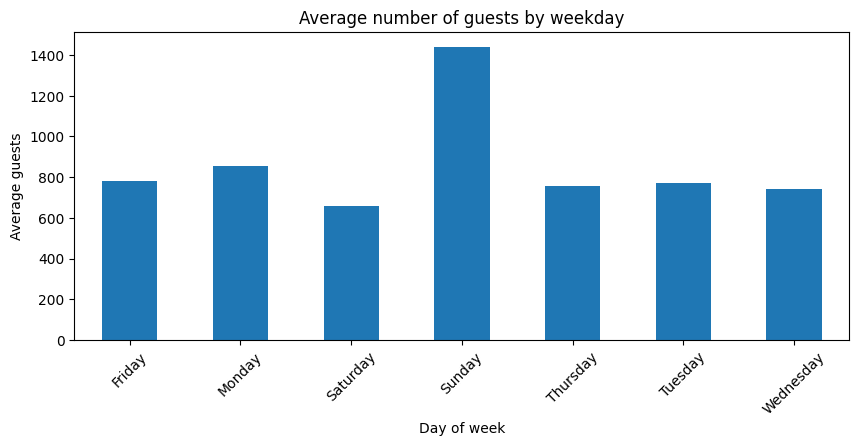

In [17]:
plt.figure(figsize=(10,4))

weekday.plot(
    kind="bar"
)

plt.title(
    "Average number of guests by weekday"
)

plt.xlabel(
    "Day of week"
)

plt.ylabel(
    "Average guests"
)

plt.xticks(rotation=45)

plt.show()

Вывод:

Посещаемость различается между днями недели.
День недели является потенциально важным признаком для модели прогнозирования.

In [18]:
df["month"] = df["date"].dt.month

In [19]:
monthly = (
    df
    .groupby("month")["guests"]
    .mean()
)

monthly

,guests
month,
1,722.514749
2,731.504792
3,759.081600
4,774.271806
5,779.290214
6,759.277357
7,752.745522
8,750.384706
9,745.613988


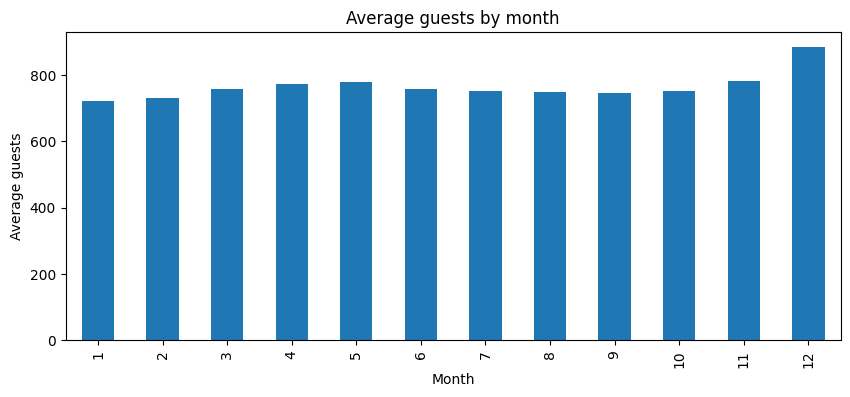

In [20]:
plt.figure(figsize=(10,4))

monthly.plot(
    kind="bar"
)

plt.title(
    "Average guests by month"
)

plt.xlabel(
    "Month"
)

plt.ylabel(
    "Average guests"
)

plt.show()

Вывод:

Среднее количество гостей отличается между месяцами, что указывает на наличие сезонных факторов.

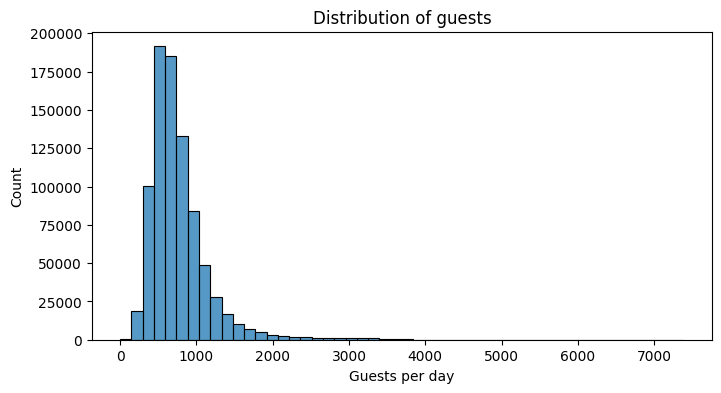

In [21]:
plt.figure(figsize=(8,4))

sns.histplot(
    df["guests"],
    bins=50
)

plt.title(
    "Distribution of guests"
)

plt.xlabel(
    "Guests per day"
)

plt.show()

Вывод:

Распределение посещаемости имеет правый хвост: некоторые точки имеют значительно больше клиентов, чем средние значения.

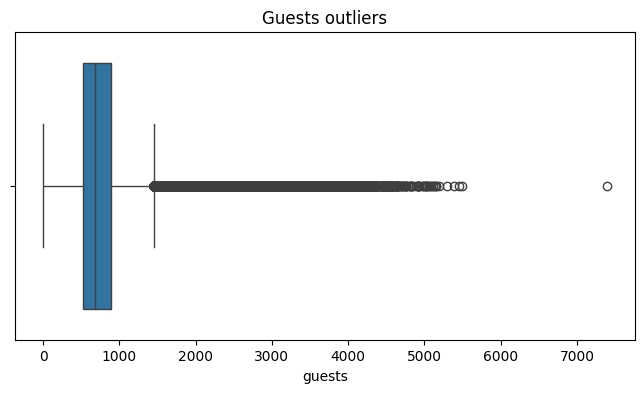

In [22]:
plt.figure(figsize=(8,4))

sns.boxplot(
    x=df["guests"]
)

plt.title(
    "Guests outliers"
)

plt.show()

Вывод:

Выбросы были выявлены, но не удалены автоматически, так как экстремальные значения могут отражать реальные события: акции, праздники или высокий спрос.